# Semi-Supervised Learning — Concepts and Math

*A companion notebook to the visual lecture — same ideas, now with runnable code and full derivations.*

Semi-supervised learning (SSL) sits between two familiar extremes:

| | uses labels? | uses unlabeled data? |
|---|---|---|
| Supervised learning | done | not done |
| Unsupervised learning | not done | done |
| **Semi-supervised learning** | a little | a lot |

**Notation used throughout this notebook**

| symbol | meaning |
|---|---|
| $L = \{(x_i, y_i)\}_{i=1}^{l}$ | the small **labeled** set |
| $U = \{x_j\}_{j=1}^{u}$ | the large **unlabeled** set, $u \gg l$ |
| $D = L \cup U$ | the full dataset |
| $\theta$ | model parameters |
| $p(y\mid x;\theta)$ | the model's predicted class distribution |
| $\hat y$ | a **pseudo-label** — a label the model invents for itself |
| $\tau$ | a confidence threshold |

Every method below answers the same question differently: **what can $U$ possibly tell us, if it carries no labels at all?**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.metrics import accuracy_score
from sklearn.calibration import calibration_curve

np.random.seed(7)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

COLORS = {"A": "#3b6fa0", "B": "#c98a3a", "U": "#9aa0a6"}
print("environment ready")

environment ready

## 1. The Data Setup

One running example carries the whole notebook: two interleaving "moons" — a classic non-linearly-separable
2-class problem. We reveal only a handful of true labels ($l=6$) and treat the rest ($u=194$) as unlabeled.

$$ D = L \cup U, \qquad L = \{(x_i,y_i)\}_{i=1}^{l},\qquad U = \{x_j\}_{j=1}^{u}, \qquad u \gg l $$

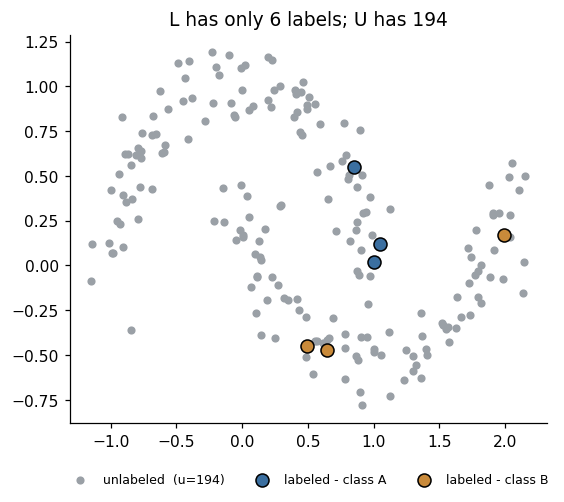

In [2]:
X, y_true = make_moons(n_samples=200, noise=0.12, random_state=7)

n_labeled = 6
rng = np.random.RandomState(7)
labeled_idx = np.concatenate([
    rng.choice(np.where(y_true == 0)[0], 3, replace=False),
    rng.choice(np.where(y_true == 1)[0], 3, replace=False),
])
unlabeled_idx = np.array([i for i in range(len(X)) if i not in labeled_idx])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(X[unlabeled_idx, 0], X[unlabeled_idx, 1], c=COLORS["U"], s=18,
           label=f"unlabeled  (u={len(unlabeled_idx)})")
mask0 = y_true[labeled_idx] == 0
ax.scatter(X[labeled_idx][mask0, 0], X[labeled_idx][mask0, 1], c=COLORS["A"], s=70,
           edgecolor="k", label="labeled - class A")
ax.scatter(X[labeled_idx][~mask0, 0], X[labeled_idx][~mask0, 1], c=COLORS["B"], s=70,
           edgecolor="k", label="labeled - class B")
ax.set_title(f"L has only {n_labeled} labels; U has {len(unlabeled_idx)}")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, fontsize=8)
plt.show()

## 2. Why Would Unlabeled Data Help At All?

Unlabeled data has no $y$. So why would seeing more $x$ without $y$ ever help predict $y$?
It only helps if the data's *geometry* is informative — and that requires at least one of three assumptions.

**1. The smoothness assumption**

$$ x_1 \approx x_2 \ \Rightarrow\ p(y\mid x_1) \approx p(y\mid x_2) $$

Nearby points share a label. This licenses the entire idea of "spreading" labels from labeled points to nearby
unlabeled ones.

**2. The low-density separation (cluster) assumption**

$$ \text{the decision boundary should pass through a region where } p(x) \text{ is small} $$

Classes form clusters; boundaries live in the gaps between clusters, not through them. Self-training, label
propagation, and semi-supervised SVMs all lean on this in different ways.

**3. The manifold assumption**

$$ x \in \mathcal{M},\qquad \dim(\mathcal{M}) \ll \dim(x) $$

High-dimensional data often lies near a much lower-dimensional curved surface. Distance should be measured
*along* that surface (geodesic), not straight through the ambient space (Euclidean) — this is what makes
graph-based methods, built from local neighborhoods, more meaningful than a raw Euclidean classifier.

None of these are guaranteed. But when one holds, $U$ stops being "just more $x$'s" — it starts tracing the
shape that $y$ has to respect.

Notice how a straight line can't respect the moon-shaped clusters -- it never gets to see them.

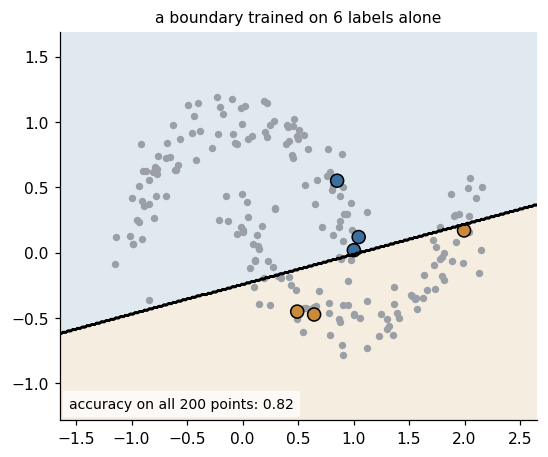

In [3]:
def plot_boundary(ax, model, X, title):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                          np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.15, cmap=ListedColormap([COLORS["A"], COLORS["B"]]))
    ax.contour(xx, yy, Z, colors="k", linewidths=1.1)
    ax.set_title(title, fontsize=10)

clf_naive = LogisticRegression().fit(X[labeled_idx], y_true[labeled_idx])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
plot_boundary(ax, clf_naive, X, "a boundary trained on 6 labels alone")
ax.scatter(X[unlabeled_idx, 0], X[unlabeled_idx, 1], c=COLORS["U"], s=14)
ax.scatter(X[labeled_idx, 0], X[labeled_idx, 1],
           c=[COLORS["A"] if v == 0 else COLORS["B"] for v in y_true[labeled_idx]],
           s=70, edgecolor="k")
acc = accuracy_score(y_true, clf_naive.predict(X))
ax.text(0.02, 0.03, f"accuracy on all 200 points: {acc:.2f}", transform=ax.transAxes,
        fontsize=9, bbox=dict(fc="white", ec="none", alpha=0.7))
plt.show()
print("Notice how a straight line can't respect the moon-shaped clusters -- it never gets to see them.")

## 3. Self-Training

The oldest and simplest SSL recipe:

1. Train a model on $L$.
2. Predict on all of $U$: $\hat y = \arg\max_y\, p(y\mid x;\theta)$.
3. Keep only the *confident* predictions: add $(x,\hat y)$ to $L$ if $\max_y p(y\mid x) > \tau$.
4. Retrain on the enlarged $L$. Repeat.

$$ \hat y = \arg\max_y\, p(y \mid x;\theta) \qquad \text{add } x \text{ to } L \text{ if } \max_y p(y\mid x) > \tau $$

The only thing keeping this from being circular is $\tau$: a high enough threshold means the model only trusts
itself where it is already almost certainly right.

round 0: labeled set size =   6   (+21 newly trusted)
round 1: labeled set size =  27   (+50 newly trusted)
round 2: labeled set size =  77   (+90 newly trusted)
round 3: labeled set size = 167   (+14 newly trusted)
round 4: labeled set size = 181   (+5 newly trusted)
round 5: labeled set size = 186   (+0 newly trusted)

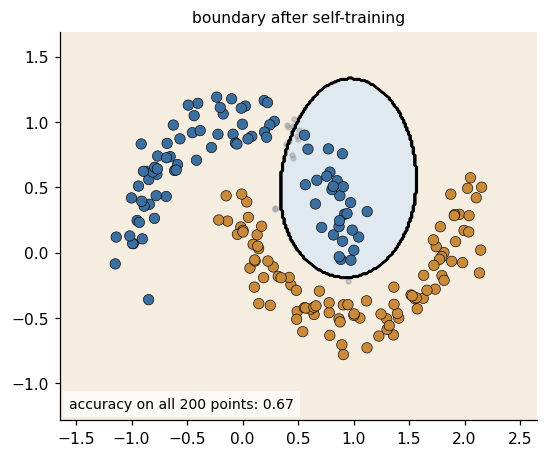

In [4]:
def self_training(X, y_true, labeled_idx, threshold=0.9, max_rounds=8):
    labeled_idx = list(labeled_idx)
    remaining = [i for i in range(len(X)) if i not in labeled_idx]
    y_train = {i: y_true[i] for i in labeled_idx}
    history = []

    clf = None
    for rnd in range(max_rounds):
        clf = SVC(kernel="rbf", probability=True, C=2.0, gamma=1.5).fit(
            X[labeled_idx], [y_train[i] for i in labeled_idx])
        if not remaining:
            break
        probs = clf.predict_proba(X[remaining])
        conf = probs.max(axis=1)
        preds = probs.argmax(axis=1)
        newly_confident = [remaining[k] for k in range(len(remaining)) if conf[k] > threshold]
        history.append({"round": rnd, "n_labeled": len(labeled_idx), "n_added": len(newly_confident)})
        if not newly_confident:
            break
        for k, i in enumerate(remaining):
            if conf[k] > threshold:
                y_train[i] = preds[k]
        labeled_idx = labeled_idx + newly_confident
        remaining = [i for i in remaining if i not in newly_confident]

    return clf, labeled_idx, history

clf_st, final_labeled, history = self_training(X, y_true, labeled_idx, threshold=0.85)

for h in history:
    print(f"round {h['round']}: labeled set size = {h['n_labeled']:>3}   (+{h['n_added']} newly trusted)")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
plot_boundary(ax, clf_st, X, "boundary after self-training")
ax.scatter(X[:, 0], X[:, 1], c=COLORS["U"], s=10, alpha=0.5)
ax.scatter(X[final_labeled, 0], X[final_labeled, 1],
           c=[COLORS["A"] if v == 0 else COLORS["B"] for v in y_true[final_labeled]],
           s=45, edgecolor="k", linewidth=0.4)
acc = accuracy_score(y_true, clf_st.predict(X))
ax.text(0.02, 0.03, f"accuracy on all 200 points: {acc:.2f}", transform=ax.transAxes,
        fontsize=9, bbox=dict(fc="white", ec="none", alpha=0.7))
plt.show()

**A note on confirmation bias.** Self-training only works as well as the model's *calibration* — whether "90%
confident" really means "right 90% of the time." If the model is overconfident, mistakes get reinforced instead
of filtered out. We can check this directly with a reliability curve.

Points below the diagonal mean 'the model claims more confidence than it has earned' -- exactly the
situation that lets self-training quietly reinforce its own mistakes.

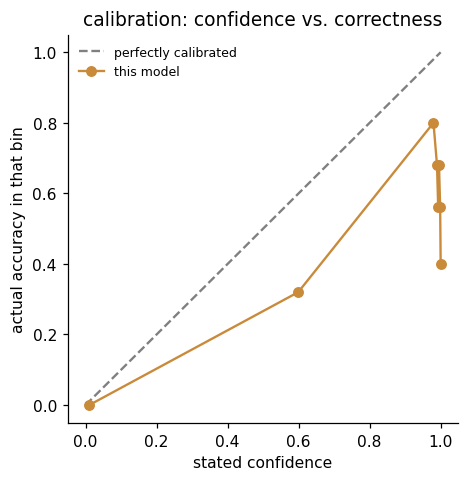

In [5]:
probs_all = clf_st.predict_proba(X)[:, 1]
frac_pos, mean_pred = calibration_curve(y_true, probs_all, n_bins=8, strategy="quantile")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfectly calibrated")
ax.plot(mean_pred, frac_pos, "o-", color=COLORS["B"], label="this model")
ax.set_xlabel("stated confidence")
ax.set_ylabel("actual accuracy in that bin")
ax.set_title("calibration: confidence vs. correctness")
ax.legend(frameon=False, fontsize=8)
plt.show()
print("Points below the diagonal mean 'the model claims more confidence than it has earned' -- exactly the")
print("situation that lets self-training quietly reinforce its own mistakes.")

## 4. Pseudo-Labeling & Entropy Minimization

**Pseudo-labeling** folds self-training directly into the loss function, instead of literally moving points
between sets:

$$ \mathcal{L} = \mathcal{L}_{\text{sup}}(L;\theta) + \lambda(t)\,\mathcal{L}_{\text{unsup}}(U;\theta), \qquad
\mathcal{L}_{\text{unsup}} = \text{CE}\bigl(\hat y,\ p(y\mid x;\theta)\bigr) $$

$\lambda(t)$ starts at 0 and ramps up — early pseudo-labels are unreliable, so they should not be trusted with
full weight from the start.

A closely related, more general idea is **entropy minimization**: instead of manufacturing a hard pseudo-label,
simply penalize the model for being *uncertain* on unlabeled data:

$$ \mathcal{L}_{\text{ent}} = -\sum_y p(y\mid x;\theta)\,\log p(y\mid x;\theta) $$

Minimizing this pushes predictions toward a confident corner — which, geometrically, pushes the *decision
boundary* away from wherever the unlabeled points sit. That is the cluster assumption again, reached from a
different direction.

p = [0.52 0.48]    entropy H = 0.999 bits
p = [0.7 0.3]    entropy H = 0.881 bits
p = [0.94 0.06]    entropy H = 0.327 bits
p = [0.99 0.01]    entropy H = 0.081 bits

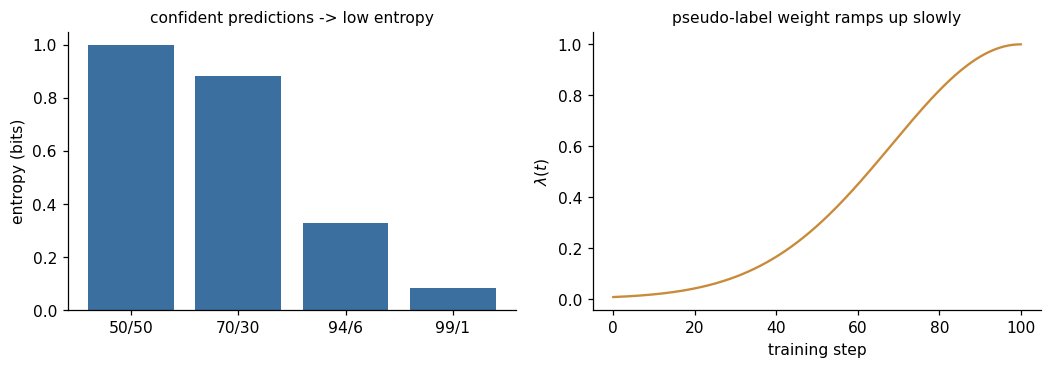

In [6]:
def entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1)
    return -(p * np.log2(p)).sum(axis=-1)

def lambda_ramp(t, T, max_lambda=1.0, k=5):
    t = np.clip(t / T, 0, 1)
    return max_lambda * np.exp(-k * (1 - t) ** 2)

example_probs = np.array([[0.52, 0.48], [0.7, 0.3], [0.94, 0.06], [0.99, 0.01]])
for p in example_probs:
    print(f"p = {p}    entropy H = {entropy(p):.3f} bits")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].bar(["50/50", "70/30", "94/6", "99/1"], [entropy(p) for p in example_probs], color=COLORS["A"])
axes[0].set_ylabel("entropy (bits)")
axes[0].set_title("confident predictions -> low entropy", fontsize=10)

t = np.linspace(0, 100, 200)
axes[1].plot(t, lambda_ramp(t, 100), color=COLORS["B"])
axes[1].set_xlabel("training step")
axes[1].set_ylabel(r"$\lambda(t)$")
axes[1].set_title("pseudo-label weight ramps up slowly", fontsize=10)
plt.tight_layout()
plt.show()

## 5. Label Propagation & Label Spreading

These methods treat the *entire dataset* — labeled and unlabeled — as nodes in a graph, connected by how similar
they are:

$$ w_{ij} = \exp\!\left(-\frac{\lVert x_i-x_j\rVert^2}{2\sigma^2}\right) $$

Stack these into a similarity matrix $W$ and a diagonal degree matrix $D_{ii}=\sum_j w_{ij}$. Let $F$ hold a
(soft) label assignment for every node. **Label propagation** repeats:

$$ F^{(t+1)} = D^{-1}WF^{(t)}, \qquad \text{then reset the rows of labeled points back to their true } Y $$

Every point's label becomes a similarity-weighted average of its neighbors' labels, re-run until it settles. This
has a beautiful equivalent formulation as an energy minimization: define

$$ E(F) = \sum_{i,j} w_{ij}\,\bigl(F(i)-F(j)\bigr)^2 = F^\top L F, \qquad L = D-W \ \ \text{(the graph Laplacian)} $$

Propagation's fixed point is *exactly* the labeling that minimizes this disagreement energy, given the labeled
rows are fixed — think of every edge as a spring pulling two labels toward agreement, and let the system settle.

**Label spreading** is the same idea with one change: instead of rigidly clamping labeled points, it lets them
drift a little too, controlled by $\alpha$:

$$ F^{*} = (1-\alpha)\,(I-\alpha S)^{-1}Y, \qquad S = D^{-1/2}WD^{-1/2},\quad 0<\alpha<1 $$

That softness makes the result more robust if one of the "true" labels was actually noisy.

In [7]:
# A tiny, fully worked example: 5 points on a line, only the two endpoints are labeled.
pts = np.array([[0, 0], [1, 0.2], [2, 0], [3.8, 0.1], [5, 0]])
labels_known = {0: 0, 4: 1}

def similarity(pts, sigma=1.2):
    d2 = ((pts[:, None, :] - pts[None, :, :]) ** 2).sum(-1)
    W = np.exp(-d2 / (2 * sigma ** 2))
    np.fill_diagonal(W, 0)
    return W

W = similarity(pts)
D = np.diag(W.sum(1))
print("W (similarity matrix):")
print(np.round(W, 2))
print("\nD (degree matrix, diagonal entries):")
print(np.round(np.diag(D), 2))

F = np.zeros((5, 2))
for i, c in labels_known.items():
    F[i, c] = 1.0

Dinv = np.diag(1 / np.diag(D))
for step in range(15):
    F = Dinv @ W @ F
    for i, c in labels_known.items():
        F[i] = 0
        F[i, c] = 1

print("\nfinal soft labels F (col 0 = class A, col 1 = class B) after 15 propagation steps:")
print(np.round(F, 3))
print("\nPoint 2 (the middle one) ends up almost exactly 50/50 -- it's equidistant from both labeled ends.")

W (similarity matrix):
[[0.   0.7  0.25 0.01 0.  ]
 [0.7  0.   0.7  0.07 0.  ]
 [0.25 0.7  0.   0.32 0.04]
 [0.01 0.07 0.32 0.   0.6 ]
 [0.   0.   0.04 0.6  0.  ]]

D (degree matrix, diagonal entries):
[0.95 1.46 1.31 1.   0.65]

final soft labels F (col 0 = class A, col 1 = class B) after 15 propagation steps:
[[1.    0.   ]
 [0.82  0.18 ]
 [0.695 0.305]
 [0.285 0.715]
 [0.    1.   ]]

Point 2 (the middle one) ends up almost exactly 50/50 -- it's equidistant from both labeled ends.

With a real similarity graph over ALL 200 points, both methods recover the moon shape from just 6 labels.

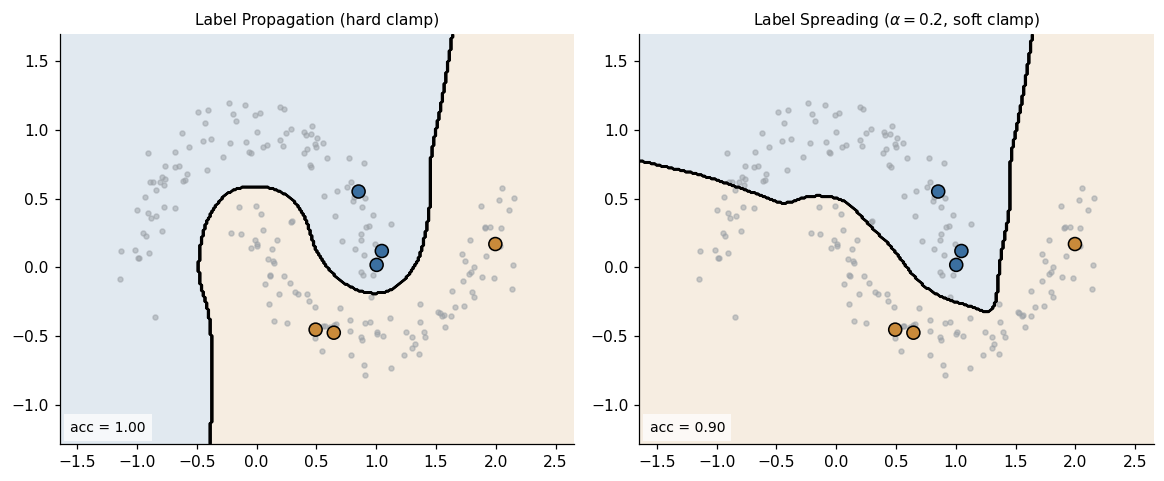

In [8]:
y_semi = np.full(len(X), -1)
y_semi[labeled_idx] = y_true[labeled_idx]

lp = LabelPropagation(kernel="rbf", gamma=20, max_iter=3000).fit(X, y_semi)
ls = LabelSpreading(kernel="rbf", gamma=20, alpha=0.2).fit(X, y_semi)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
for ax, model, name in zip(axes, [lp, ls],
                            ["Label Propagation (hard clamp)", r"Label Spreading ($\alpha=0.2$, soft clamp)"]):
    plot_boundary(ax, model, X, name)
    ax.scatter(X[:, 0], X[:, 1], c=COLORS["U"], s=10, alpha=0.5)
    ax.scatter(X[labeled_idx, 0], X[labeled_idx, 1],
               c=[COLORS["A"] if v == 0 else COLORS["B"] for v in y_true[labeled_idx]],
               s=70, edgecolor="k")
    acc = accuracy_score(y_true, model.predict(X))
    ax.text(0.02, 0.03, f"acc = {acc:.2f}", transform=ax.transAxes, fontsize=9,
            bbox=dict(fc="white", ec="none", alpha=0.7))
plt.tight_layout()
plt.show()
print("With a real similarity graph over ALL 200 points, both methods recover the moon shape from just 6 labels.")

## 6. Co-Training

Co-training assumes the features naturally split into two *views*, each sufficient on its own and (ideally)
conditionally independent given $y$:

$$ x = (x^{(1)}, x^{(2)}), \qquad y \perp x^{(2)} \mid x^{(1)}\ \ (\text{and vice versa}) $$

Train one classifier per view on $L$. Each classifier then labels the unlabeled points *it* is most confident
about, and those pseudo-labels are handed to the *other* view's training set:

$$ \text{add } x \text{ to } L_2 \text{ if } h_1(x) \text{ is confident}, \qquad
\text{add } x \text{ to } L_1 \text{ if } h_2(x) \text{ is confident} $$

Below, two artificial "views" of the same moons data (independent noise on top of the same underlying geometry)
stand in for genuinely different feature sets, purely to demonstrate the mechanics.

In [9]:
rng2 = np.random.RandomState(3)
X_view1 = X + rng2.normal(0, 0.05, X.shape)
X_view2 = X + rng2.normal(0, 0.05, X.shape)

def co_training(X1, X2, y_true, labeled_idx, rounds=25, growth_per_class=3):
    # Classic co-training: each round, each view teaches the OTHER view its
    # top-k most confident predictions per class (Blum & Mitchell, 1998).
    l1 = list(labeled_idx); l2 = list(labeled_idx)
    y1 = {i: y_true[i] for i in l1}; y2 = {i: y_true[i] for i in l2}
    pool = [i for i in range(len(X1)) if i not in labeled_idx]
    h1 = h2 = None
    for r in range(rounds):
        h1 = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True).fit(X1[l1], [y1[i] for i in l1])
        h2 = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True).fit(X2[l2], [y2[i] for i in l2])
        if not pool:
            break
        p1 = h1.predict_proba(X1[pool])
        p2 = h2.predict_proba(X2[pool])
        added = set()
        for cls in [0, 1]:                                    # h1 teaches L2
            idxs = sorted([k for k in range(len(pool)) if p1[k].argmax() == cls], key=lambda k: -p1[k][cls])
            for k in idxs[:growth_per_class]:
                i = pool[k]
                if i not in y2:
                    y2[i] = cls; l2.append(i); added.add(i)
        for cls in [0, 1]:                                    # h2 teaches L1
            idxs = sorted([k for k in range(len(pool)) if p2[k].argmax() == cls], key=lambda k: -p2[k][cls])
            for k in idxs[:growth_per_class]:
                i = pool[k]
                if i not in y1:
                    y1[i] = cls; l1.append(i); added.add(i)
        pool = [i for i in pool if i not in added]
        if r < 4 or r % 5 == 0 or not added:
            print(f"round {r:>2}: |L1|={len(l1):>3}   |L2|={len(l2):>3}   (+{len(added)} exchanged)")
        if not added:
            break
    return h1, h2

h1, h2 = co_training(X_view1, X_view2, y_true, labeled_idx)
acc1 = accuracy_score(y_true, h1.predict(X_view1))
acc2 = accuracy_score(y_true, h2.predict(X_view2))
print(f"\nfinal accuracy -- view-1 classifier: {acc1:.2f}    view-2 classifier: {acc2:.2f}")

round  0: |L1|= 12   |L2|= 12   (+7 exchanged)
round  1: |L1|= 18   |L2|= 18   (+12 exchanged)
round  2: |L1|= 24   |L2|= 24   (+11 exchanged)
round  3: |L1|= 30   |L2|= 30   (+11 exchanged)
round  5: |L1|= 42   |L2|= 42   (+10 exchanged)
round 10: |L1|= 72   |L2|= 72   (+8 exchanged)
round 15: |L1|=102   |L2|=102   (+10 exchanged)
round 20: |L1|=132   |L2|=132   (+7 exchanged)

final accuracy -- view-1 classifier: 0.93    view-2 classifier: 0.93

## 7. The Consistency-Regularization Family

A large modern family of SSL methods shares one recipe: perturb an unlabeled input twice, and penalize the model
for disagreeing with itself.

$$ \mathcal{L}_{\text{cons}} = d\bigl(f(T_1(x)),\, f(T_2(x))\bigr), \qquad
T = \text{a stochastic perturbation (noise, augmentation, dropout, ...)} $$

Below are small, self-contained illustrations of three well-known members of this family.

### 7a. Mean Teacher

Instead of two live noisy passes, Mean Teacher keeps a second copy of the model — the **teacher** — whose weights
are an exponential moving average (EMA) of the **student**'s weights. The teacher never receives a gradient
update directly:

$$ \theta'_{t} = \alpha\,\theta'_{t-1} + (1-\alpha)\,\theta_t, \qquad
\mathcal{L}_{\text{cons}} = \bigl\lVert f(x;\theta,\xi) - f(x;\theta',\xi')\bigr\rVert^2 $$

A moving average is, by construction, smoother than the thing it is averaging — so the teacher gives a steadier
target than the fast-moving student could give itself.

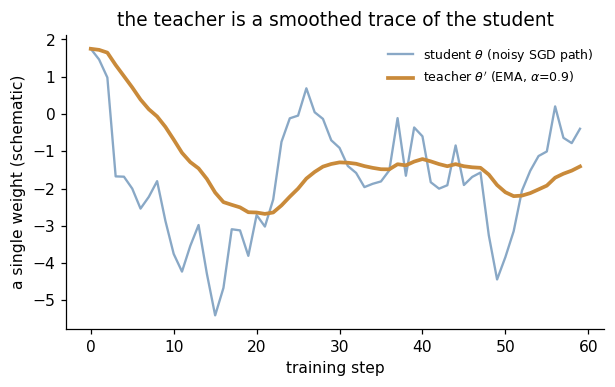

In [10]:
rng3 = np.random.RandomState(11)
steps = 60
student = np.cumsum(rng3.normal(0, 1, steps))  # a noisy "random-walk" training trajectory, schematic only
alpha = 0.9
teacher = np.zeros(steps)
teacher[0] = student[0]
for t in range(1, steps):
    teacher[t] = alpha * teacher[t - 1] + (1 - alpha) * student[t]

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(student, color=COLORS["A"], alpha=0.6, label=r"student $\theta$ (noisy SGD path)")
ax.plot(teacher, color=COLORS["B"], linewidth=2.4, label=fr"teacher $\theta'$ (EMA, $\alpha$={alpha})")
ax.set_xlabel("training step")
ax.set_ylabel("a single weight (schematic)")
ax.legend(frameon=False, fontsize=8)
ax.set_title("the teacher is a smoothed trace of the student")
plt.show()

### 7b. FixMatch

FixMatch applies two different strengths of augmentation to the *same* unlabeled point. The weak view produces a
pseudo-label only if the model is confident about it; that pseudo-label then becomes the training target for the
model's prediction on the *strong* view:

$$ \mathcal{L} = \mathbb{1}\bigl[\max_y p(y\mid \text{weak}(x)) > \tau\bigr]\cdot
\text{CE}\Bigl(\arg\max_y p(y\mid\text{weak}(x)),\ p(\cdot\mid\text{strong}(x))\Bigr) $$

Below, the classifier trained earlier scores a weakly- and a strongly-perturbed version of ten unlabeled points,
and we see exactly which ones pass the confidence gate.

In [11]:
tau = 0.85
sample_idx = unlabeled_idx[:10]
X_weak = X[sample_idx] + rng.normal(0, 0.03, X[sample_idx].shape)
X_strong = X[sample_idx] + rng.normal(0, 0.25, X[sample_idx].shape)

p_weak = clf_st.predict_proba(X_weak)
p_strong = clf_st.predict_proba(X_strong)
conf_weak = p_weak.max(1)
pseudo = p_weak.argmax(1)
mask = conf_weak > tau

print(f"{'point':>6} {'weak conf':>10} {'passes tau?':>12} {'pseudo-label':>13} {'strong pred':>12}")
for i in range(len(sample_idx)):
    print(f"{i:>6} {conf_weak[i]:>10.2f} {'yes' if mask[i] else 'no':>12} "
          f"{pseudo[i]:>13} {p_strong[i].argmax():>12}")

kept = int(mask.sum())
print(f"\n{kept}/{len(sample_idx)} points cleared the confidence gate and contribute to the loss this round.")

 point  weak conf  passes tau?  pseudo-label  strong pred
     0       1.00          yes             1            1
     1       1.00          yes             1            1
     2       1.00          yes             0            0
     3       1.00          yes             0            0
     4       0.99          yes             1            1
     5       0.91          yes             0            1
     6       1.00          yes             1            1
     7       0.99          yes             1            1
     8       1.00          yes             1            1
     9       1.00          yes             1            1

10/10 points cleared the confidence gate and contribute to the loss this round.

### 7c. MixMatch

MixMatch (1) averages predictions across several augmentations of the same point, (2) **sharpens** that average
toward a confident corner, then (3) **mixes** the result with real labeled data:

$$ \text{sharpen: } p_i \leftarrow \frac{p_i^{1/T}}{\sum_j p_j^{1/T}} \qquad
\text{mixup: } \tilde x = \lambda x_1+(1-\lambda)x_2,\ \ \tilde y=\lambda y_1+(1-\lambda)y_2 $$

Lower temperature $T$ sharpens harder. $\lambda$ is drawn from a Beta distribution, so most mixed points sit
close to one of the two originals, with occasional interpolations in between.

T= 1.0:  sharpened = [0.55 0.45]   entropy = 0.993 bits
T= 0.5:  sharpened = [0.599 0.401]   entropy = 0.972 bits
T=0.25:  sharpened = [0.691 0.309]   entropy = 0.893 bits

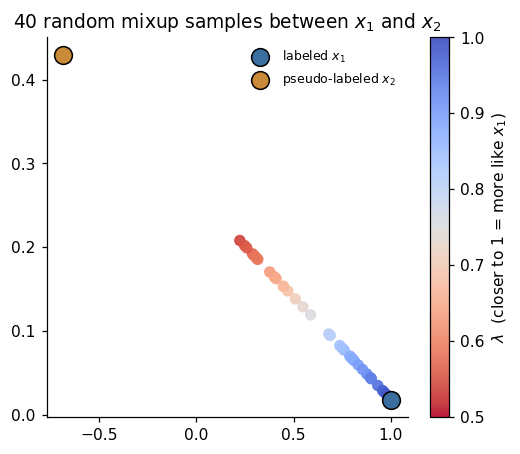

In [12]:
def sharpen(p, T=0.5):
    p = p ** (1 / T)
    return p / p.sum(axis=-1, keepdims=True)

avg_pred = np.array([0.55, 0.45])
for T in [1.0, 0.5, 0.25]:
    sharpened = sharpen(avg_pred, T)
    print(f"T={T:>4}:  sharpened = {np.round(sharpened, 3)}   entropy = {entropy(sharpened):.3f} bits")

def mixup(x1, y1, x2, y2, alpha=0.75, rng=None):
    rng = rng or np.random
    lam = rng.beta(alpha, alpha)
    lam = max(lam, 1 - lam)  # MixMatch convention: keep the mix closer to x1
    x_tilde = lam * x1 + (1 - lam) * x2
    y_tilde = lam * y1 + (1 - lam) * y2
    return x_tilde, y_tilde, lam

x1, y1_ = X[labeled_idx[0]], np.array([1., 0.])
x2, y2_ = X[unlabeled_idx[0]], np.array([0., 1.])  # pretend this came from a pseudo-label
rngm = np.random.RandomState(2)
mixed_pts = [mixup(x1, y1_, x2, y2_, rng=rngm) for _ in range(40)]

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(*x1, c=COLORS["A"], s=130, edgecolor="k", zorder=3, label=r"labeled $x_1$")
ax.scatter(*x2, c=COLORS["B"], s=130, edgecolor="k", zorder=3, label=r"pseudo-labeled $x_2$")
mx = np.array([m[0] for m in mixed_pts])
lam_vals = np.array([m[2] for m in mixed_pts])
sc = ax.scatter(mx[:, 0], mx[:, 1], c=lam_vals, cmap="coolwarm_r", s=40, alpha=0.9, vmin=0.5, vmax=1.0)
plt.colorbar(sc, ax=ax, label=r"$\lambda$  (closer to 1 = more like $x_1$)")
ax.legend(frameon=False, fontsize=8)
ax.set_title(r"40 random mixup samples between $x_1$ and $x_2$")
plt.show()

## 8. Summary

| method | core equation | what makes it distinct |
|---|---|---|
| Self-Training | $\hat y=\arg\max_y p(y\mid x)$, add if $>\tau$ | the original recipe; simplest, most prone to confirmation bias |
| Pseudo-Labeling | $\mathcal L=\mathcal L_{sup}+\lambda(t)\mathcal L_{unsup}$ | folds self-training into the loss with a ramp-up |
| Entropy Minimization | $\mathcal L_{ent}=-\sum p\log p$ | no hard label needed — just reward confidence |
| Label Propagation | $F^{(t+1)}=D^{-1}WF^{(t)}$, hard clamp | transductive; labels diffuse over a similarity graph |
| Label Spreading | $F^{*}=(1-\alpha)(I-\alpha S)^{-1}Y$ | same graph, soft clamp — robust to label noise |
| Co-Training | agree across two views to teach each other | needs (at least approximately) independent views |
| Mean Teacher | $\theta'_t=\alpha\theta'_{t-1}+(1-\alpha)\theta_t$ | EMA of *weights* gives a stable consistency target |
| FixMatch | masked CE between weak and strong views | only confident weak predictions get to teach |
| MixMatch | sharpen + mixup | blends augmentation, sharpening, and labeled data into one loss |

**The one idea underneath all of them:**

$$ \min_\theta\ \ \mathcal L_{\text{sup}}(L;\theta) \ +\ \lambda\cdot \mathcal L_{\text{unsup}}(U;\theta) $$

Every method above is a different, creative answer to one question: *what should* $\mathcal L_{\text{unsup}}$
*even be, when there is no label to compute a loss against?*

### Further reading (by name — search for these directly)

- Self-training — Yarowsky (1995)
- Co-training — Blum & Mitchell (1998)
- Label Propagation — Zhu & Ghahramani (2002)
- Label Spreading — Zhou et al. (2004)
- Entropy Minimization — Grandvalet & Bengio (2005)
- Mean Teacher — Tarvainen & Valpola (2017)
- MixMatch — Berthelot et al. (2019)
- FixMatch — Sohn et al. (2020)